# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [53]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import math


Image size: (336, 332)


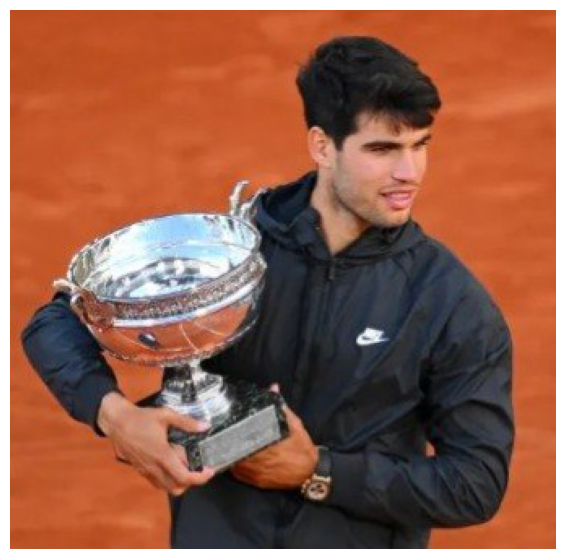

In [30]:
# ── Load image ────────────────────────────────────
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("CarlitosRG24.jpg")

print("Image size:", img.size)

plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [31]:
# Get the size of the image
w, h = img.size

print("Original size:", w, h)

cx = 2
cy = 2


Original size: 336 332


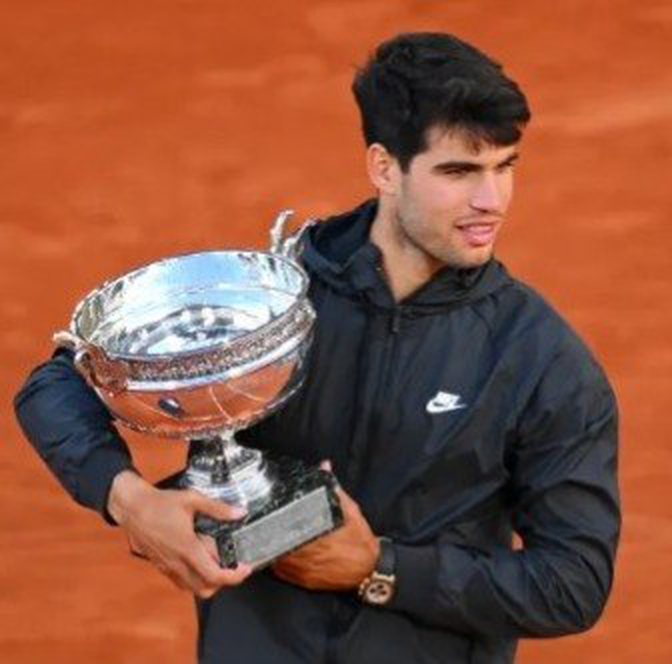

In [32]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (int(w * cx), int(h * cy)),
    Image.Resampling.LANCZOS
)

scaled_img

In [33]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)


Original size: (336, 332)
Scaled size: (672, 664)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

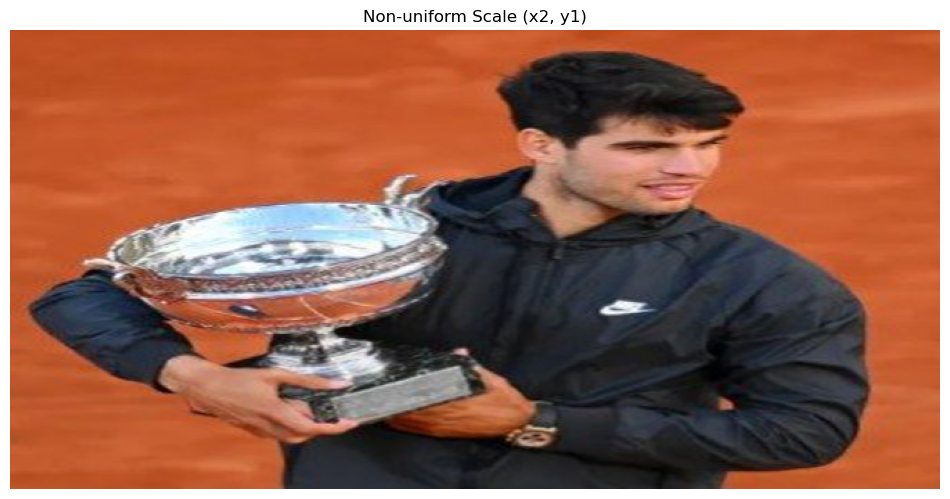

In [34]:
cx = 2
cy = 1

non_uniform_img = img.resize(
    (int(w * cx), int(h * cy)),
    Image.Resampling.LANCZOS
)

plt.figure(figsize=(12, 7))
plt.imshow(non_uniform_img)
plt.title("Non-uniform Scale (x2, y1)")
plt.axis("off")
plt.show()

In [35]:
non_uniform_img.save("task1_1_nonuniform.jpg")

print("Original size:", img.size)
print("Non-uniform size:", non_uniform_img.size)

Original size: (336, 332)
Non-uniform size: (672, 332)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

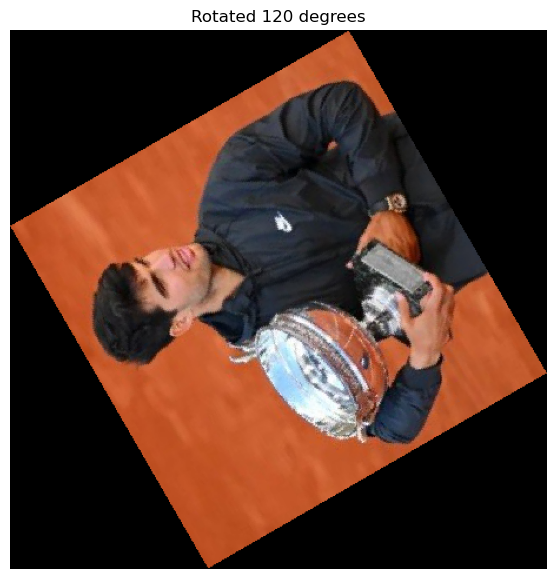

Original size: (336, 332)
Rotated size: (456, 458)


In [36]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(
    120,
    expand=True
)

plt.figure(figsize=(12, 7))
plt.imshow(rotated_img)
plt.title("Rotated 120 degrees")
plt.axis("off")
plt.show()
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)


### 3. Shear

In [37]:
# -- c. Get the image dimensions ────────────────────
w, h = img.size

print("Image size:", w, h)


Image size: 336 332


In [38]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0

new_w = int(w + abs(shx) * h)
new_h = int(h + abs(shy) * w)

print("New size:", new_w, new_h)


New size: 502 332


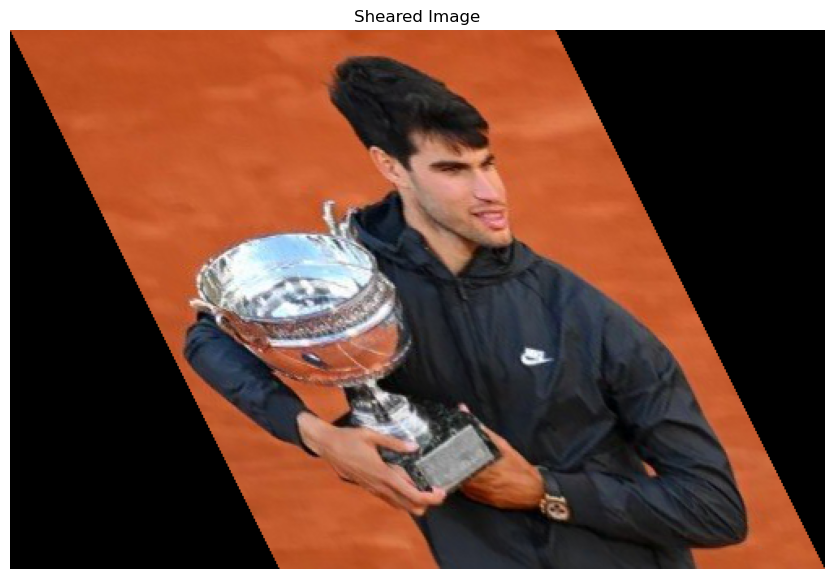

In [39]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_w, new_h),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.figure(figsize=(12, 7))
plt.imshow(sheared_img)
plt.title("Sheared Image")
plt.axis("off")
plt.show()


In [40]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

print("Saved successfully!")


Saved successfully!


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

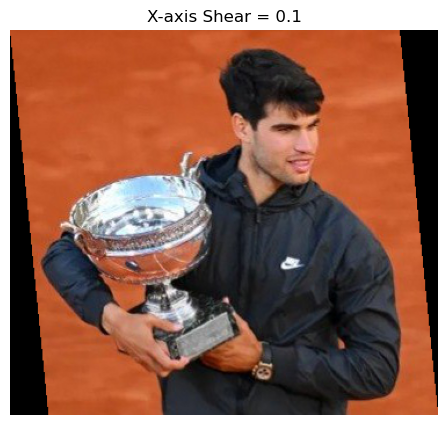

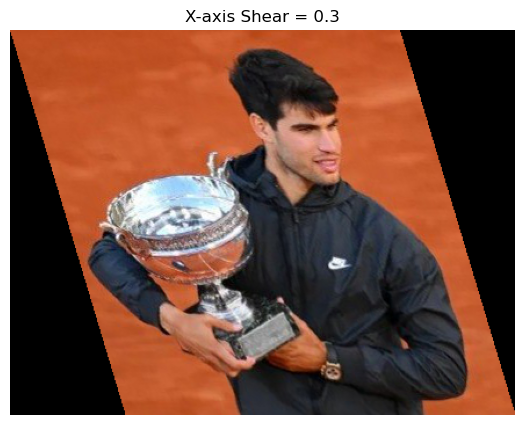

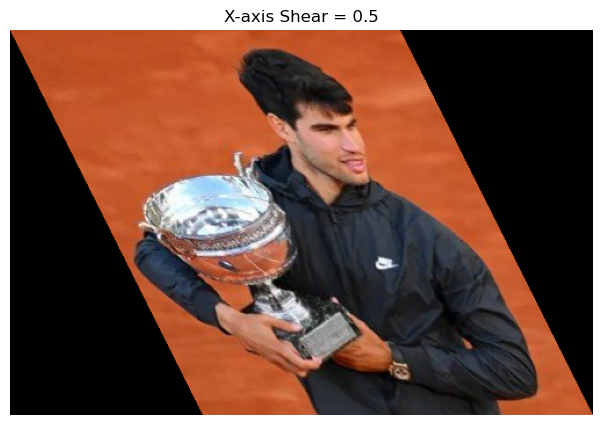

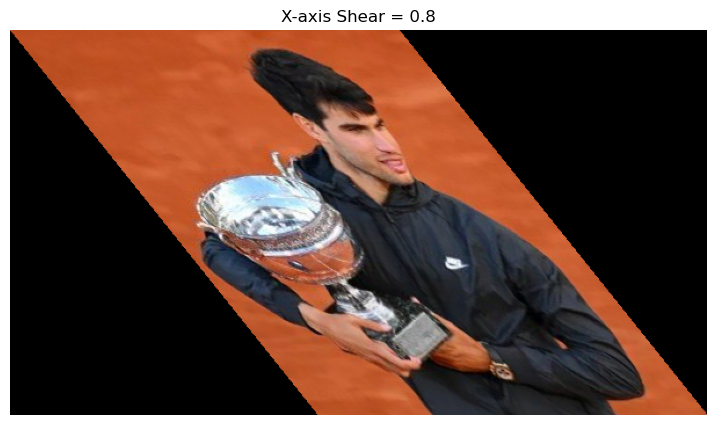

In [42]:
for shx in [0.1, 0.3, 0.5, 0.8]:

    new_w = int(w + abs(shx) * h)
    new_h = h

    test_img = img.transform(
        (new_w, new_h),
        Image.Transform.AFFINE,
        (1, -shx, 0, 0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    plt.figure(figsize=(10, 5))
    plt.imshow(test_img)
    plt.title(f"X-axis Shear = {shx}")
    plt.axis("off")
    plt.show()

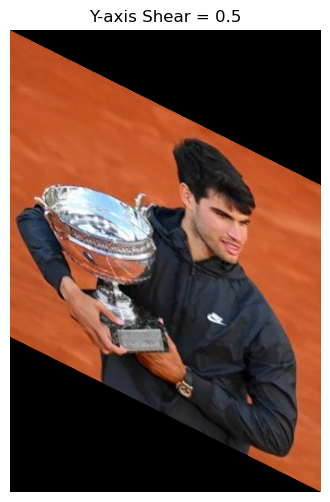

In [54]:
shx = 0
shy = 0.5

new_w = w
new_h = int(h + abs(shy) * w)

y_shear_img = img.transform(
    (new_w, new_h),
    Image.Transform.AFFINE,
    (1, 0, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.figure(figsize=(10, 6))
plt.imshow(y_shear_img)
plt.title("Y-axis Shear = 0.5")
plt.axis("off")
plt.show()

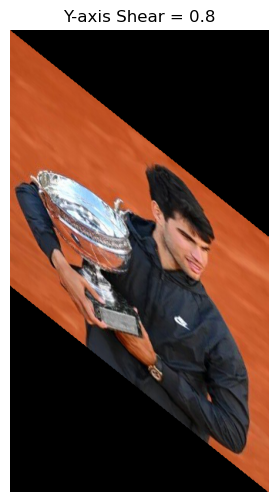

In [55]:
shy = 0.8

new_w = w
new_h = int(h + abs(shy) * w)

y_shear_img = img.transform(
    (new_w, new_h),
    Image.Transform.AFFINE,
    (1, 0, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.figure(figsize=(10, 6))
plt.imshow(y_shear_img)
plt.title("Y-axis Shear = 0.8")
plt.axis("off")
plt.show()

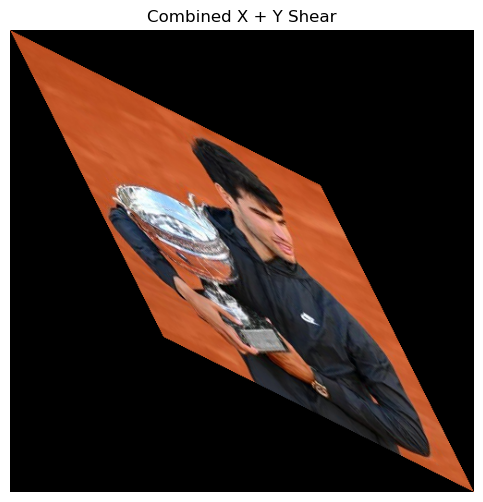

In [56]:
# Combine X and Y shear

shx = 0.5
shy = 0.5

det = 1 - (shx * shy)

a = 1 / det
b = -shx / det
d = -shy / det
e = 1 / det

new_w = int(w + abs(shx) * h)
new_h = int(h + abs(shy) * w)

xy_shear_img = img.transform(
    (new_w, new_h),
    Image.Transform.AFFINE,
    (a, b, 0, d, e, 0),
    resample=Image.Resampling.BICUBIC
)

plt.figure(figsize=(10, 6))
plt.imshow(xy_shear_img)
plt.title("Combined X + Y Shear")
plt.axis("off")
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

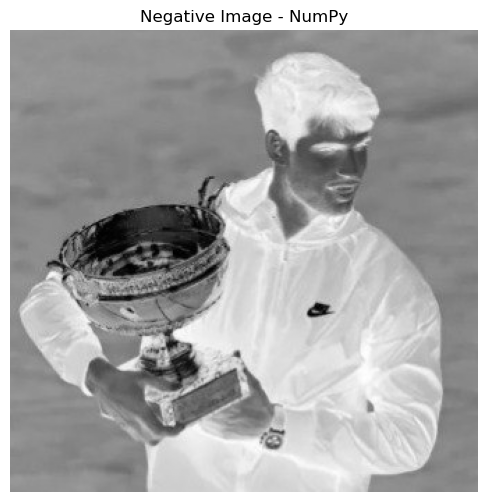

In [49]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation


arr = np.array(img.convert("L"))

negative_arr = 255 - arr

negative_img = Image.fromarray(negative_arr)

plt.figure(figsize=(10, 6))
plt.imshow(negative_img, cmap="gray")
plt.title("Negative Image - NumPy")
plt.axis("off")
plt.show()



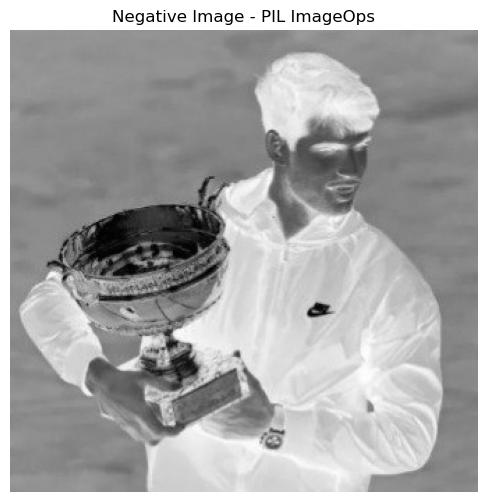

In [50]:
# Method 2: PIL's ImageOps

negative_img2 = ImageOps.invert(img.convert("L"))

plt.figure(figsize=(10, 6))
plt.imshow(negative_img2, cmap="gray")
plt.title("Negative Image - PIL ImageOps")
plt.axis("off")
plt.show()

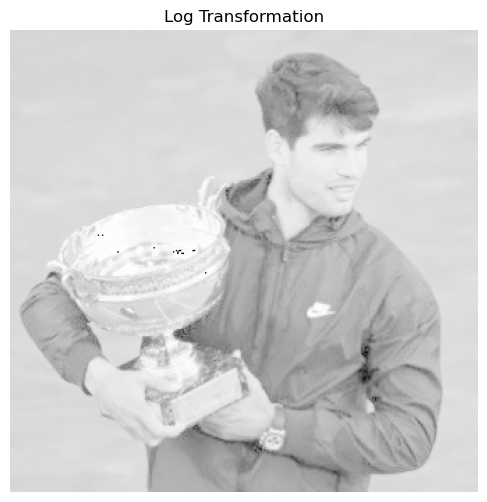

In [51]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel


arr = np.array(img.convert("L"))

c = 255 / math.log(1 + 255)

log_arr = c * np.log(1 + arr)

log_arr = np.uint8(log_arr)

log_img = Image.fromarray(log_arr)

plt.figure(figsize=(10, 6))
plt.imshow(log_img, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")
plt.show()


In [ ]:

# ── 3. Power-law / Gamma correction ───────────────


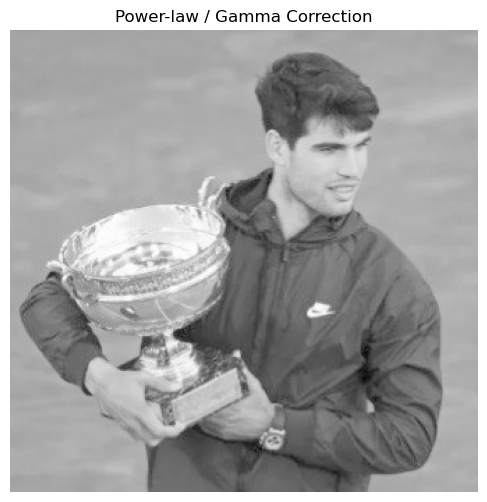

In [52]:


arr = np.array(img.convert("L"), dtype=np.float64)

gamma = 0.5

gamma_arr = 255 * ((arr / 255) ** gamma)

gamma_img = Image.fromarray(
    np.uint8(np.clip(gamma_arr, 0, 255))
)

plt.figure(figsize=(10, 6))
plt.imshow(gamma_img, cmap="gray")
plt.title("Power-law / Gamma Correction")
plt.axis("off")
plt.show()